In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import normaltest, skew, boxcox
import statsmodels.api as sm

In [26]:
sns.set_style('darkgrid')

In [27]:
df = pd.read_csv(
    filepath_or_buffer='data/Country-data.csv'
)

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,Gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [28]:
df.drop(
    columns=['country'],
    axis=1,
    inplace=True
)

df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,Gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [29]:
df.isnull().sum()

child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
Gdpp          0
dtype: int64

In [30]:
df.dtypes.to_frame(name='dtype')

,dtype
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
Gdpp,int64


In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.nunique().sort_values()

life_expec    127
total_fer     138
child_mort    139
exports       147
health        147
imports       151
inflation     156
income        156
Gdpp          157
dtype: int64

In [33]:
df.shape

(167, 9)

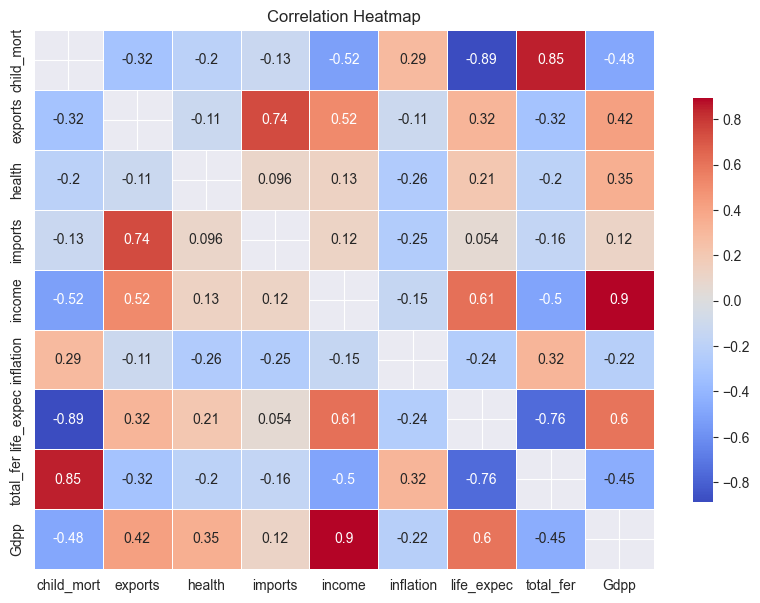

In [34]:
# HeatMap ile Multicollinearity inceledik
corr = df.corr()

np.fill_diagonal(corr.values, np.nan)

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={
        'shrink':0.75
    }
)
plt.title('Correlation Heatmap')
plt.show()

In [35]:
X = df.drop(columns=['Gdpp'])

y = df['Gdpp']

In [36]:
X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13


In [37]:
y[0:5]

0      553
1     4090
2     4460
3     3530
4    12200
Name: Gdpp, dtype: int64

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((133, 8), (34, 8), (133,), (34,))

In [40]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
X_train_scaled

array([[-0.83746628, -0.46960119,  1.02705834, ..., -0.59499747,
         1.1087671 , -0.70605991],
       [-0.29757844, -0.03846097, -0.99004398, ...,  0.67078917,
         0.68784703, -0.08237768],
       [-0.598059  ,  0.50257773, -0.31521816, ..., -0.63332824,
         0.34446486, -0.93109988],
       ...,
       [-0.83013748,  0.51103146, -0.4590335 , ...,  0.58367378,
         0.01215954, -0.98253759],
       [-0.71043384,  0.02071513,  0.08672728, ..., -0.55405324,
         0.41092593, -0.99539702],
       [-0.54431451, -0.00464606,  1.78669834, ...,  0.23521221,
        -0.06537837, -1.12399129]], shape=(133, 8))

In [42]:
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)

In [43]:
ols = sm.OLS(y_train, X_train_sm).fit()

print(ols.summary())

# Hata --> y - y^

                            OLS Regression Results                            
Dep. Variable:                   Gdpp   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     101.3
Date:                Thu, 26 Feb 2026   Prob (F-statistic):           1.19e-50
Time:                        20:01:36   Log-Likelihood:                -1365.3
No. Observations:                 133   AIC:                             2749.
Df Residuals:                     124   BIC:                             2775.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.321e+04    624.340     21.154      0.0

In [44]:
y_pred = ols.predict(X_test_sm)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_absolute_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(
    f'Test R2: {r2:.4f}\n'
    f'Test RMSE: {rmse:.2f}\n'
    f'Test MAE: {mae:.2f}'
)

Test R2: 0.8268
Test RMSE: 68.49
Test MAE: 4690.96


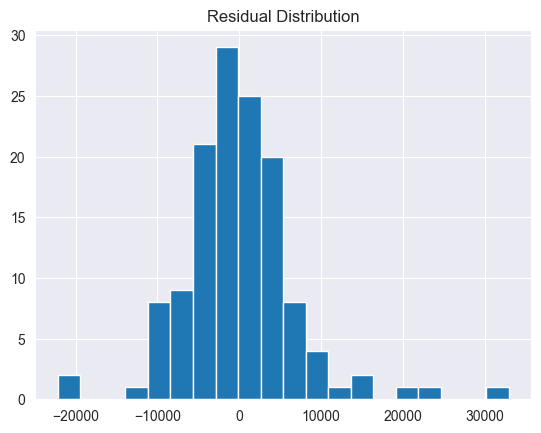

In [45]:
resid = y_train - ols.predict(X_train_sm)

plt.hist(resid, bins=20)
plt.title('Residual Distribution')
plt.show()

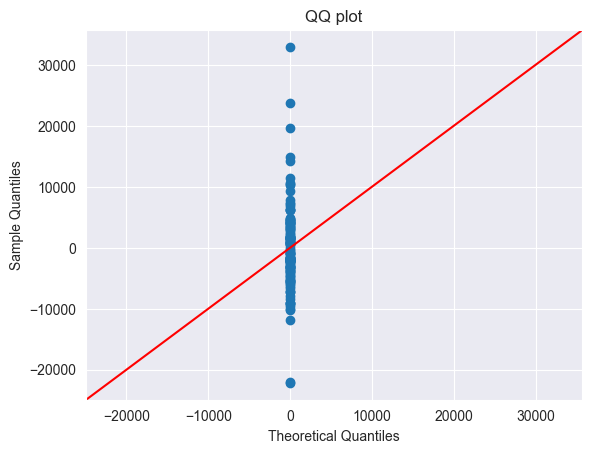

In [46]:
sm.qqplot(resid, line='45')
plt.title('QQ plot')
plt.show()

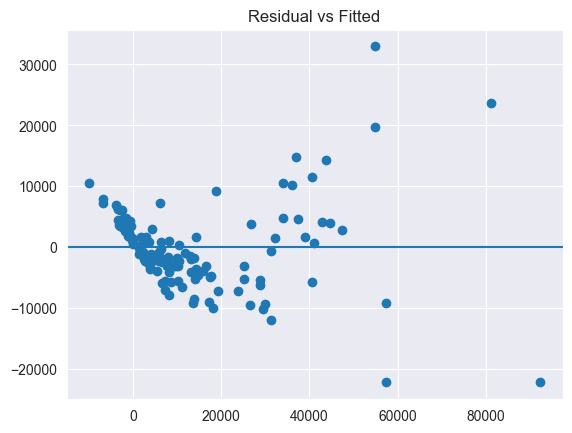

In [47]:
plt.scatter(ols.predict(X_train_sm), resid)

plt.axhline(0)
plt.title('Residual vs Fitted')
plt.show()

In [49]:
bp = het_breuschpagan(resid, X_train_sm)

print(
    f'LM p-value: {bp[1]}\n'
    f'F p-value: {bp[3]}'
)

LM p-value: 1.6871001238115892e-10
F p-value: 4.7941440114914644e-14


In [50]:
ols_robust = ols.get_robustcov_results(cov_type='HC3')
print(ols_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                   Gdpp   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     34.91
Date:                Thu, 26 Feb 2026   Prob (F-statistic):           2.59e-28
Time:                        20:08:56   Log-Likelihood:                -1365.3
No. Observations:                 133   AIC:                             2749.
Df Residuals:                     124   BIC:                             2775.
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.321e+04    712.104     18.547      0.0

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

print(
    f'RIDGE\n'
    f'R2: {r2_score(y_test, ridge_pred)}\n'
    f'RMSE: {np.sqrt(mean_squared_error(y_test, ridge_pred))}\n'
    f'MAE: {mean_absolute_error(y_test, ridge_pred)}'
)

RIDGE
R2: 0.8299355231213902
RMSE: 6035.4835333257015
MAS: 4663.912395603624


In [57]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)

print(
    f'LOSSO\n'
    f'R2: {r2_score(y_test, lasso_pred)}\n'
    f'RMSE: {np.sqrt(mean_squared_error(y_test, lasso_pred))}\n'
    f'MAE: {mean_absolute_error(y_test, lasso_pred)}'
)

LOSSO
R2: 0.8267909119442662
RMSE: 6091.028101809116
MAE: 4690.777513595381


In [58]:
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train_scaled, y_train)
elastic_pred = elastic.predict(X_test_scaled)

print(
    f'ELASTIC\n'
    f'R2: {r2_score(y_test, elastic_pred)}\n'
    f'RMSE: {np.sqrt(mean_squared_error(y_test, elastic_pred))}\n'
    f'MAE: {mean_absolute_error(y_test, elastic_pred)}'
)

ELASTIC
R2: 0.8413352064321578
RMSE: 5829.691205695288
MAE: 4578.8423741495135


In [59]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'ridge': ridge.coef_,
    'lasso': lasso.coef_,
    'elastic': elastic.coef_
})

coef_df

,feature,ridge,lasso,elastic
0,child_mort,3374.523857,3643.788773,2360.142058
1,exports,1507.892918,1386.366069,1968.933079
2,health,4666.511181,4667.196945,4600.356261
3,imports,-427.765944,-340.757431,-722.015253
4,income,15145.312608,15344.347110,14150.142847
5,inflation,-927.588857,-921.407969,-937.191772
6,life_expec,3905.725895,4069.723331,3353.189216
7,total_fer,841.518487,809.623644,860.194314
